# EJEMPLO TRATAMIENTO DE NULOS

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import style

import seaborn as sns

import missingno as msno

%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")

style.use('ggplot') or plt.style.use('ggplot')

## Carga del archivo 'muestra_nulos.csv'

In [3]:
RUTA = 'https://raw.githubusercontent.com/SonikoKatsura/CURSO_PARO_IA/refs/heads/main/Rober_IA/Modulo2/datos/muestra_nulos.csv'

df_muestra = pd.read_csv(RUTA)

df_muestra.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   edad              50 non-null     float64
 1   peso              50 non-null     float64
 2   IQ                35 non-null     float64
 3   anios_trabajados  42 non-null     float64
 4   sueldo_medio      16 non-null     float64
dtypes: float64(5)
memory usage: 2.1 KB


## ANALISIS COLUMNAS CON NULOS CON LIBRERÍA MISSINGNO

### Primer vistazo con 'matrix' y 'bar':

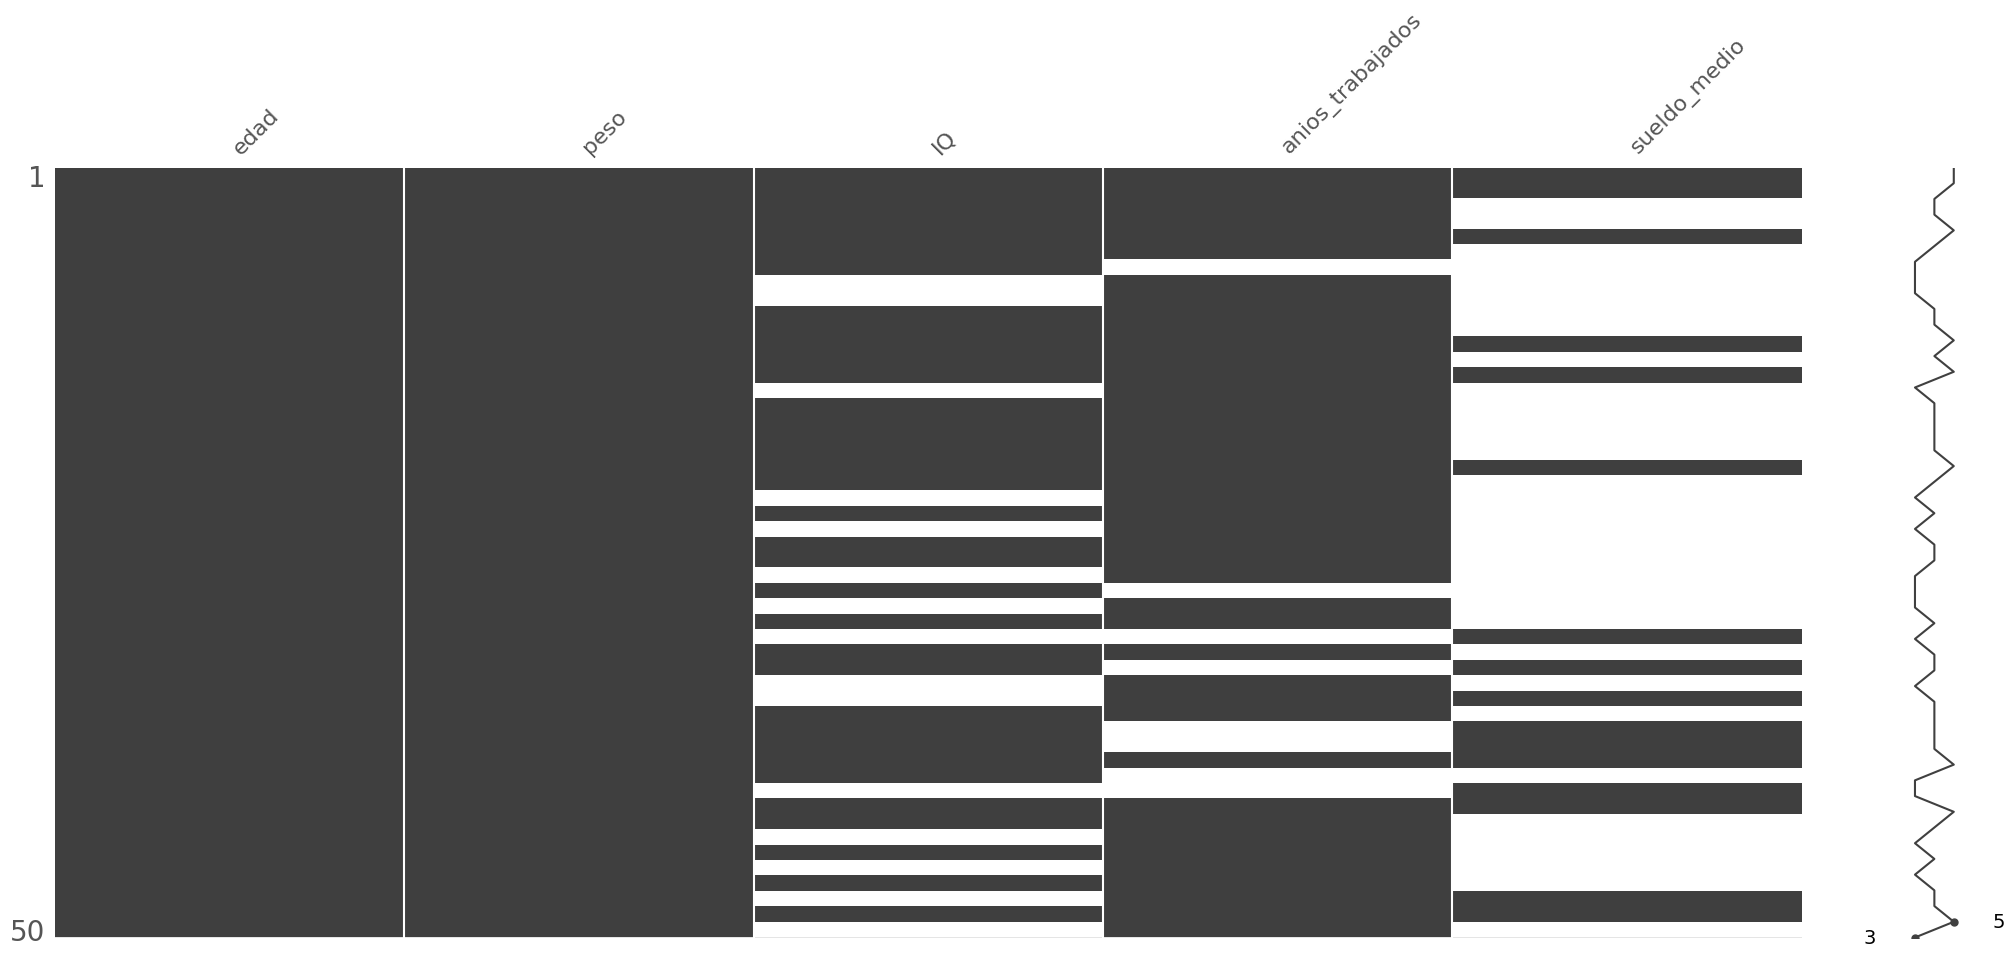

In [4]:
msno.matrix(df_muestra);

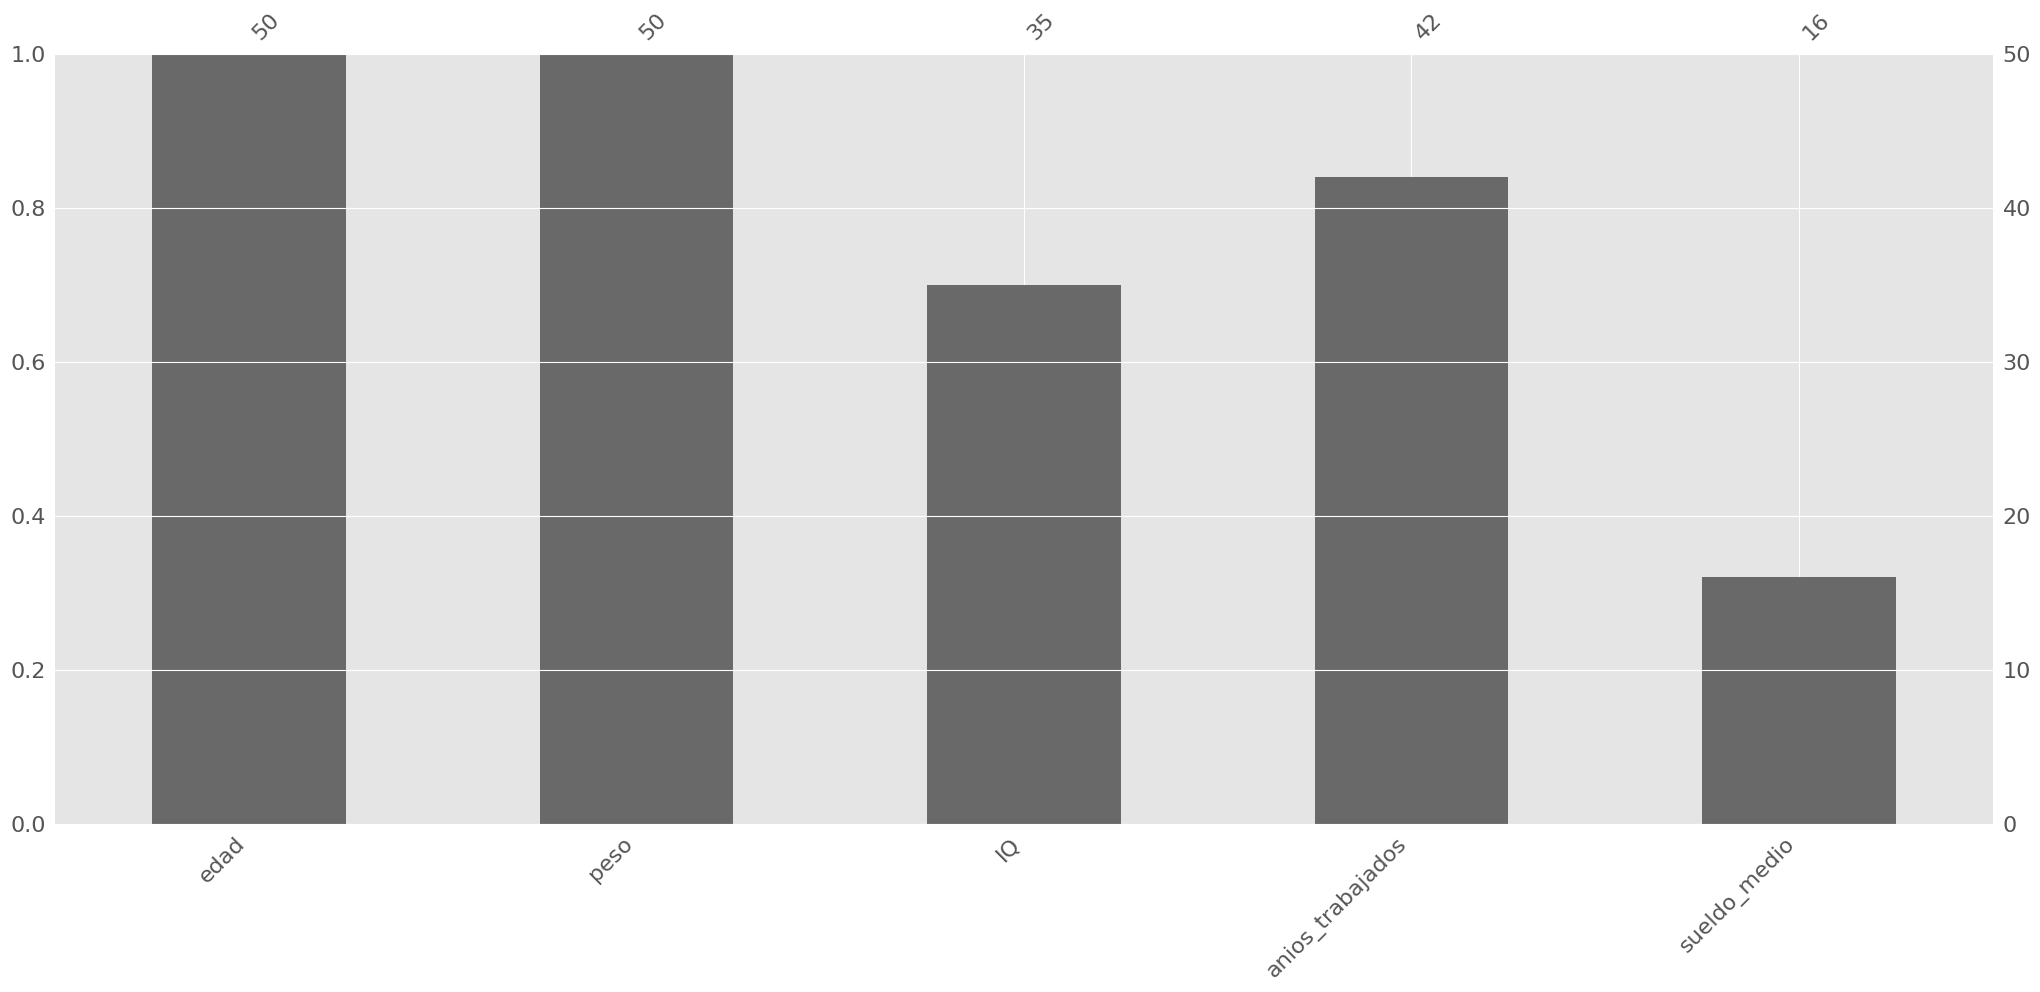

In [5]:
msno.bar(df_muestra);

#### Primera conclusión: demasiados nulos en columna "sueldo_medio" (70% aprox.), decidimos eliminarla

In [6]:
df_muestra.drop(columns='sueldo_medio', inplace=True)

df_muestra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   edad              50 non-null     float64
 1   peso              50 non-null     float64
 2   IQ                35 non-null     float64
 3   anios_trabajados  42 non-null     float64
dtypes: float64(4)
memory usage: 1.7 KB


### Examinar columnas con nulos: IQ y anios_trabajados

En la gráfica 'matrix' anterior no se observa nigún patrón en la disposición de los nulos en ambas, parece que los nulos estan colocados al azar, lo que nos llevaría a pensar en nulos completamente aleatorios (MCAR), pero aquí siempre es necesario profundizar un poco mas.

### Columna IQ

Aislamos el dataframe cuyas filas tienen nulo en IQ. Comparamos las distribuciones de las columnas en este DF respecto al original:

In [7]:
df_muestra[df_muestra.IQ.isnull()].describe()

,edad,peso,IQ,anios_trabajados
count,15.000000,15.000000,0.0,13.000000
mean,61.760667,87.051333,NaN,35.384615
std,4.889434,21.534662,NaN,14.442636
min,55.260000,28.520000,NaN,8.000000
25%,58.095000,79.280000,NaN,26.000000
50%,61.830000,88.830000,NaN,32.000000
75%,64.355000,103.715000,NaN,44.000000
max,70.940000,113.130000,NaN,62.000000


In [8]:
df_muestra.describe()

,edad,peso,IQ,anios_trabajados
count,50.000000,50.000000,35.000000,42.000000
mean,50.542000,87.861000,115.173143,39.119048
std,9.063425,21.303987,15.021384,15.484378
min,34.760000,28.520000,90.070000,8.000000
25%,44.250000,78.005000,98.785000,28.250000
50%,48.800000,88.405000,118.350000,39.500000
75%,56.312500,101.277500,125.700000,49.000000
max,70.940000,152.800000,136.930000,91.000000


Observamos que hay una clara diferencia en la columna edad. Parece que los nulos en IQ sólo se dan para valores altos de edad, que hay cierta dependencia.
Para confirmarlo dibujamos de nuevo el gráfico 'matrix', pero con el DF ordenado por edad

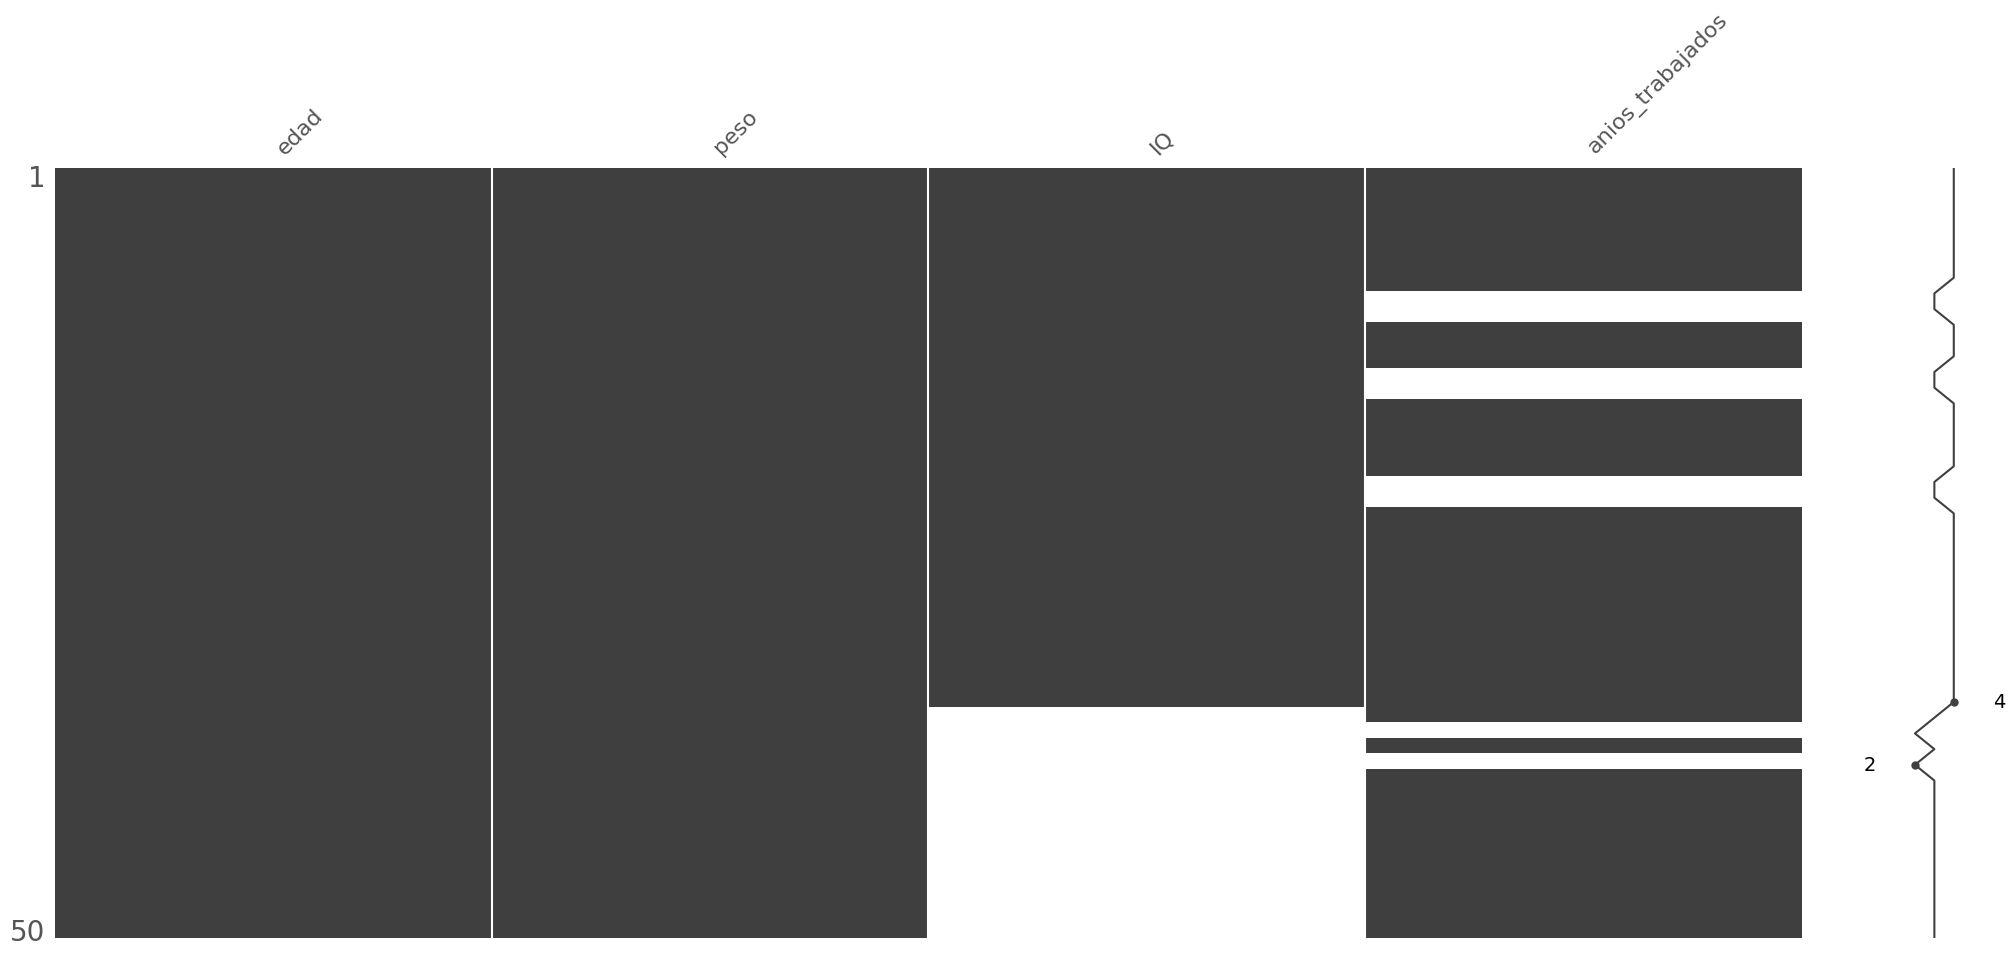

In [9]:
msno.matrix(df_muestra.sort_values('edad'));

Efectivamente ahora observamos ese patrón, los nulos se localizan en los valores altos de edad. Por lo tanto lo que nos parecia en principio completamente aleatorio no lo es, hay dependencia con datos existentes de otra columna: nulos MAR

### Columna anios_trabajados

Procedemos de la misma forma:

In [10]:
df_muestra[df_muestra.anios_trabajados.isnull()].describe()

,edad,peso,IQ,anios_trabajados
count,8.000000,8.000000,6.000000,0.0
mean,48.043750,79.526250,114.395000,NaN
std,5.900181,27.815946,18.065236,NaN
min,42.190000,28.520000,90.860000,NaN
25%,44.230000,69.247500,99.772500,NaN
50%,46.290000,76.750000,118.125000,NaN
75%,50.057500,97.657500,127.762500,NaN
max,57.750000,117.850000,134.630000,NaN


In [11]:
df_muestra.describe()

,edad,peso,IQ,anios_trabajados
count,50.000000,50.000000,35.000000,42.000000
mean,50.542000,87.861000,115.173143,39.119048
std,9.063425,21.303987,15.021384,15.484378
min,34.760000,28.520000,90.070000,8.000000
25%,44.250000,78.005000,98.785000,28.250000
50%,48.800000,88.405000,118.350000,39.500000
75%,56.312500,101.277500,125.700000,49.000000
max,70.940000,152.800000,136.930000,91.000000


array([[<Axes: title={'center': 'edad'}>,
        <Axes: title={'center': 'peso'}>],
       [<Axes: title={'center': 'IQ'}>,
        <Axes: title={'center': 'anios_trabajados'}>]], dtype=object)

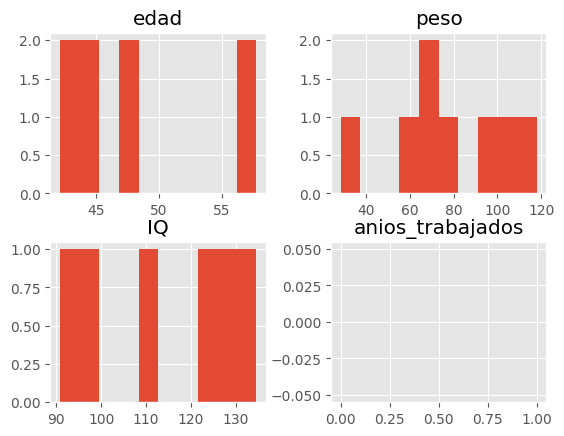

In [12]:
df_muestra[df_muestra.anios_trabajados.isnull()].hist()

array([[<Axes: title={'center': 'edad'}>,
        <Axes: title={'center': 'peso'}>],
       [<Axes: title={'center': 'IQ'}>,
        <Axes: title={'center': 'anios_trabajados'}>]], dtype=object)

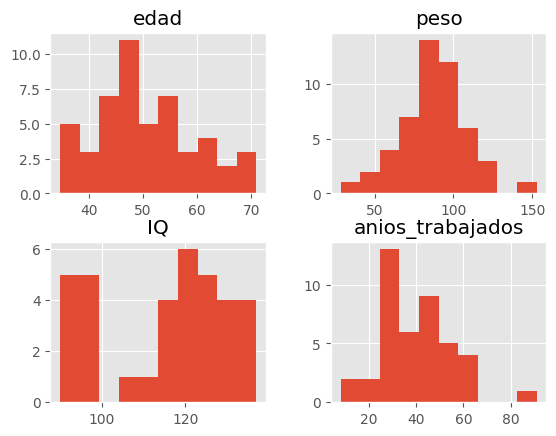

In [13]:
df_muestra.hist()

No se aprecia cambios en la distribucion de variables considerable.
Dibujamos de nuevo el gráfico 'matrix' con el DF ordenado por edad y peso

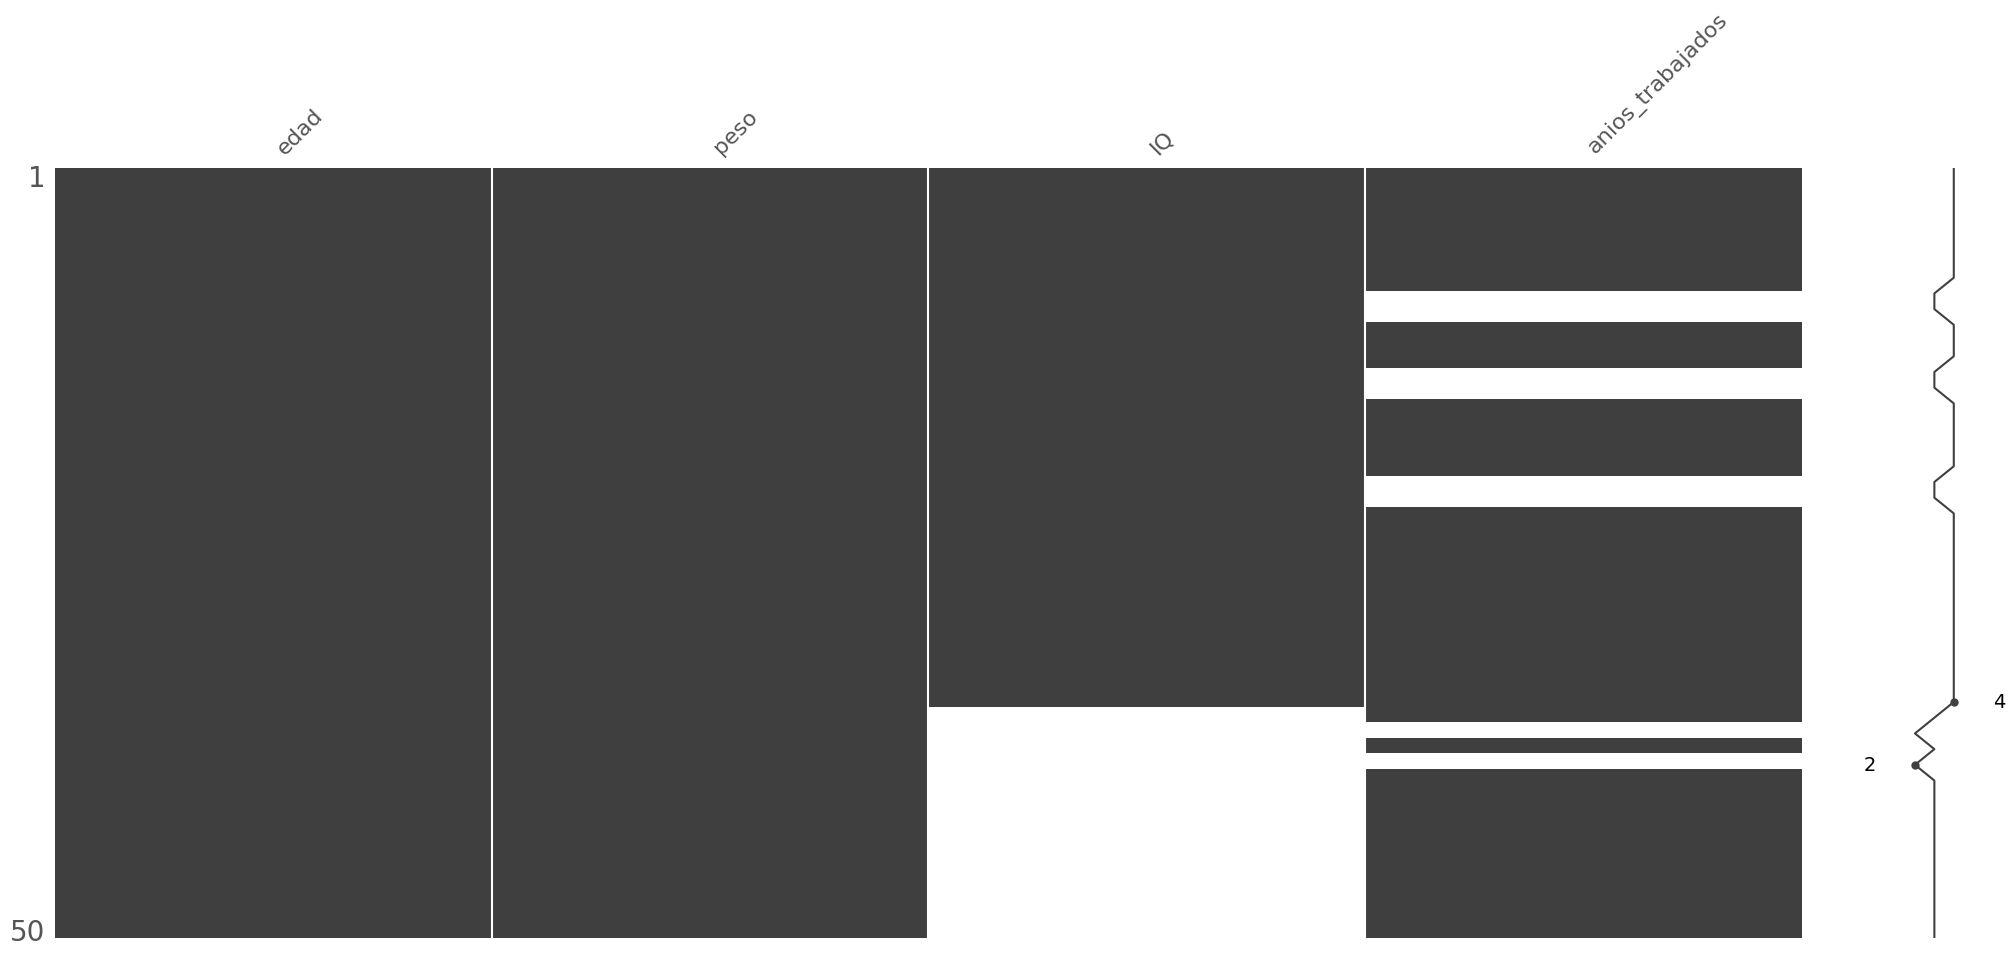

In [14]:
msno.matrix(df_muestra.sort_values('edad'));

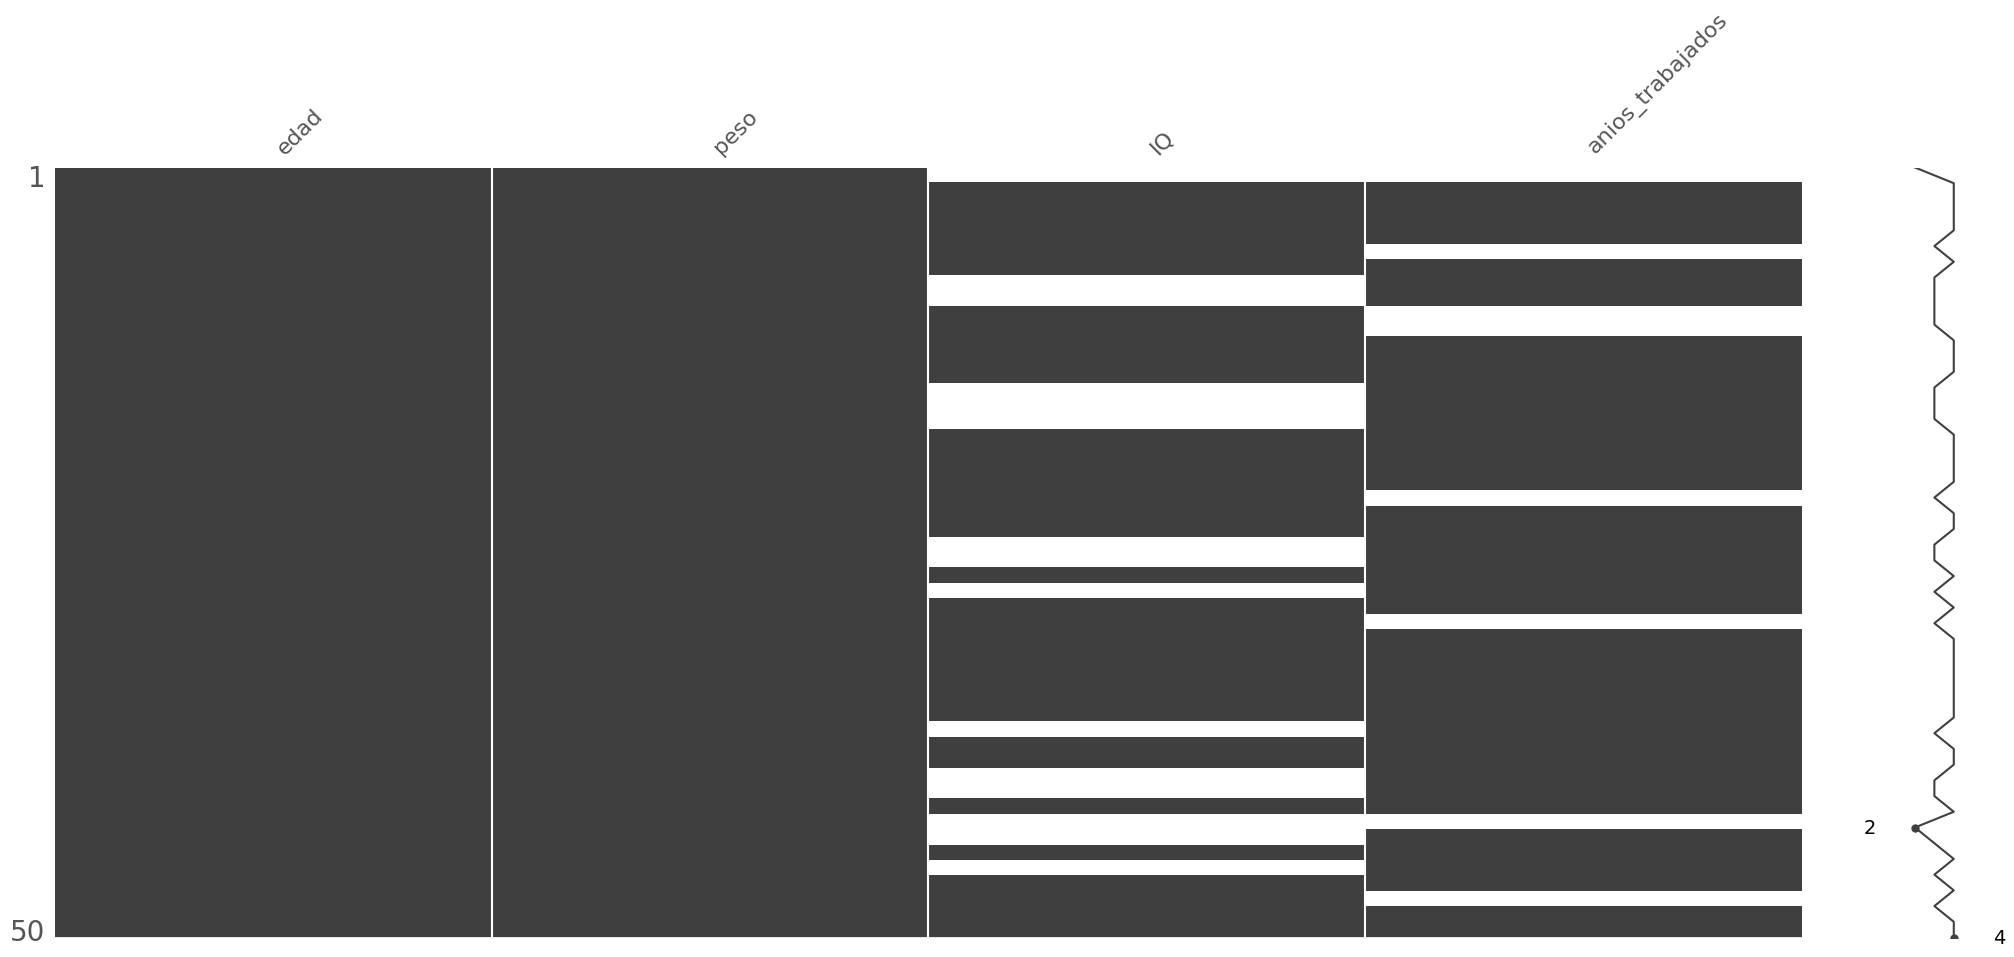

In [15]:
msno.matrix(df_muestra.sort_values('peso'));

Efectivamente no vemos ningún patrón, ninguna relación. Por lo tanto lo que nos parecia en principio completamente aleatorio se confirma: nulos MCAR

### Correlación entre valores nulos

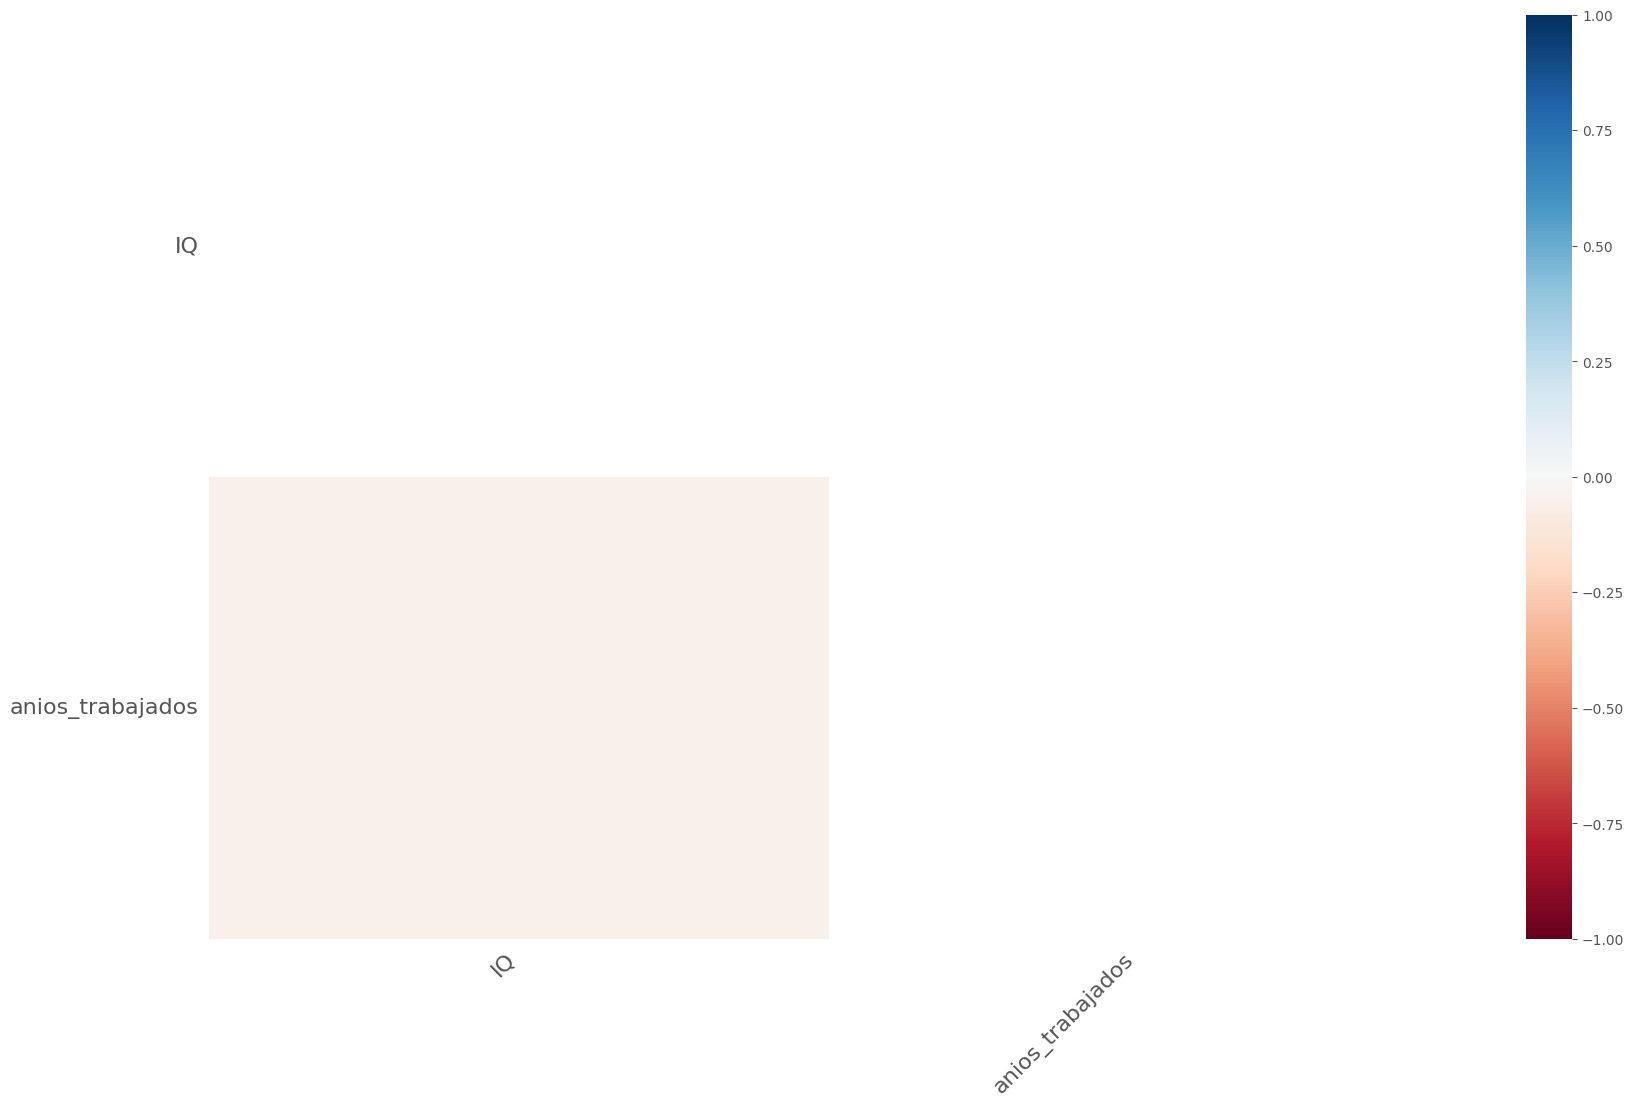

In [16]:
msno.heatmap(df_muestra);

Como podemos ver no hay correlacion entre los valores nulos de las columnas con dichos valores.

En caso afirmativo (valores cercanos al -1 o al 1) en el par de variables involucradas habría correlacón de valores nulos, no serían MCAR ni MAR, sino MNAR